# Real-data results: parity, scarcity, and the CFS comparison

Five public benchmarks where causal discovery is feasible (fico, german, heart, mammographic, ilpd); hepatitis sits below that regime and is shown at the end as the boundary case. TB stays internal. The arms:
- **vanilla**: plain FasterRisk, no prior.
- **ours** (GES, IAMB): FasterRisk with a soft causal-discovery prior, two versions differing only in the discovery algorithm.
- **CFS** (valid mi-cg, naive Fisher-Z): the other way to use causal information, hard-picking features first, then fitting.

All numbers are held-out test AUC over many random splits; the ± and error bars are the spread across those splits. Plotting lives in `src/causal_prior/cfs_results.py`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[2]))

from src.causal_prior import cfs_results as cr

runs = cr.load_runs()

## FICO: does adding the prior cost accuracy?
Our method and vanilla as the scorecard size *k* grows, error bars for the spread across splits.

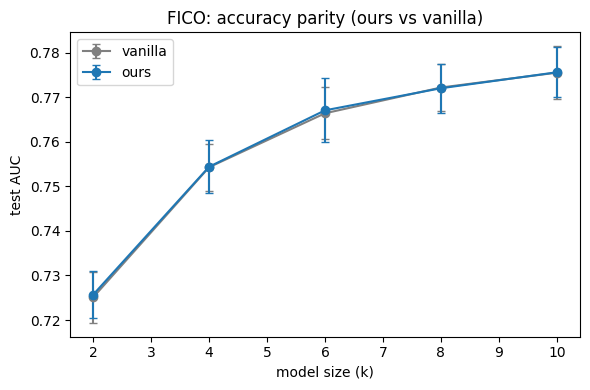

In [2]:
cr.plot_parity()

*The two lines lie on top of each other: the prior changes which features are picked, not the accuracy.*

## FICO: what happens as the data gets scarce?
The same FICO data, shrinking the training set from 1200 down to 150 rows.

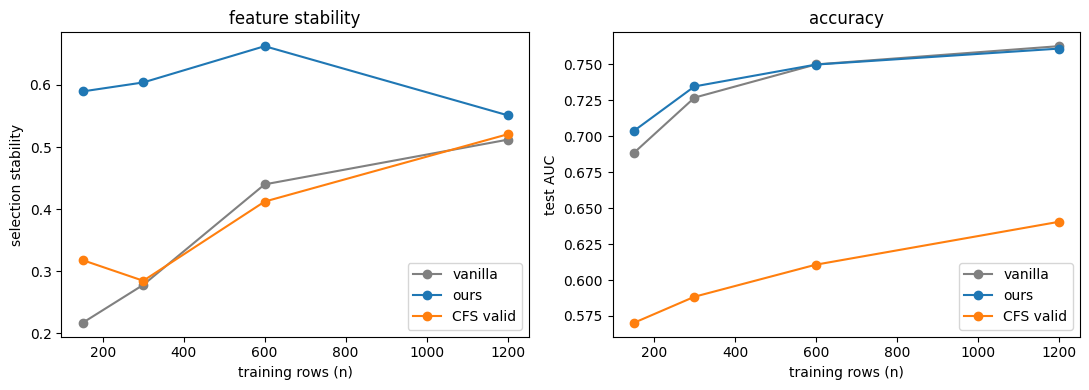

In [3]:
cr.plot_scarcity(runs)

*Left: our method keeps a far more stable feature set than vanilla, and the gap is largest when data is scarcest. Right: accuracy stays level with vanilla and well above the valid CFS baseline.*

## All five benchmarks: test AUC
Mean ± spread across splits, one row per benchmark, one column per arm.

In [4]:
cr.auc_table(runs)

,vanilla,ours (GES),ours (IAMB),"ours (IAMB, Fisher-Z)",CFS valid (mi-cg),CFS naive (Fisher-Z),CFS naive (HITON)
fico,0.763 ±0.033,0.761 ±0.026,0.762 ±0.030,0.764 ±0.019,0.640 ±0.061,0.765 ±0.018,0.764 ±0.017
heart,0.894 ±0.033,0.894 ±0.036,0.903 ±0.033,0.883 ±0.036,0.861 ±0.031,0.869 ±0.030,0.858 ±0.037
mammographic,0.864 ±0.014,0.863 ±0.014,0.865 ±0.015,0.862 ±0.014,0.826 ±0.020,0.827 ±0.018,0.819 ±0.018
ilpd,0.696 ±0.036,0.704 ±0.038,0.705 ±0.035,0.686 ±0.040,0.705 ±0.039,0.581 ±0.035,0.581 ±0.034
german,0.729 ±0.025,0.735 ±0.027,0.731 ±0.023,0.732 ±0.025,0.698 ±0.042,0.722 ±0.023,0.727 ±0.019


*Our method sits at or above vanilla and above every CFS baseline. Overlapping ranges mean no reliable difference.*

## The same AUCs as a chart
Each benchmark, every arm, dashed line at vanilla, error bars for the spread.

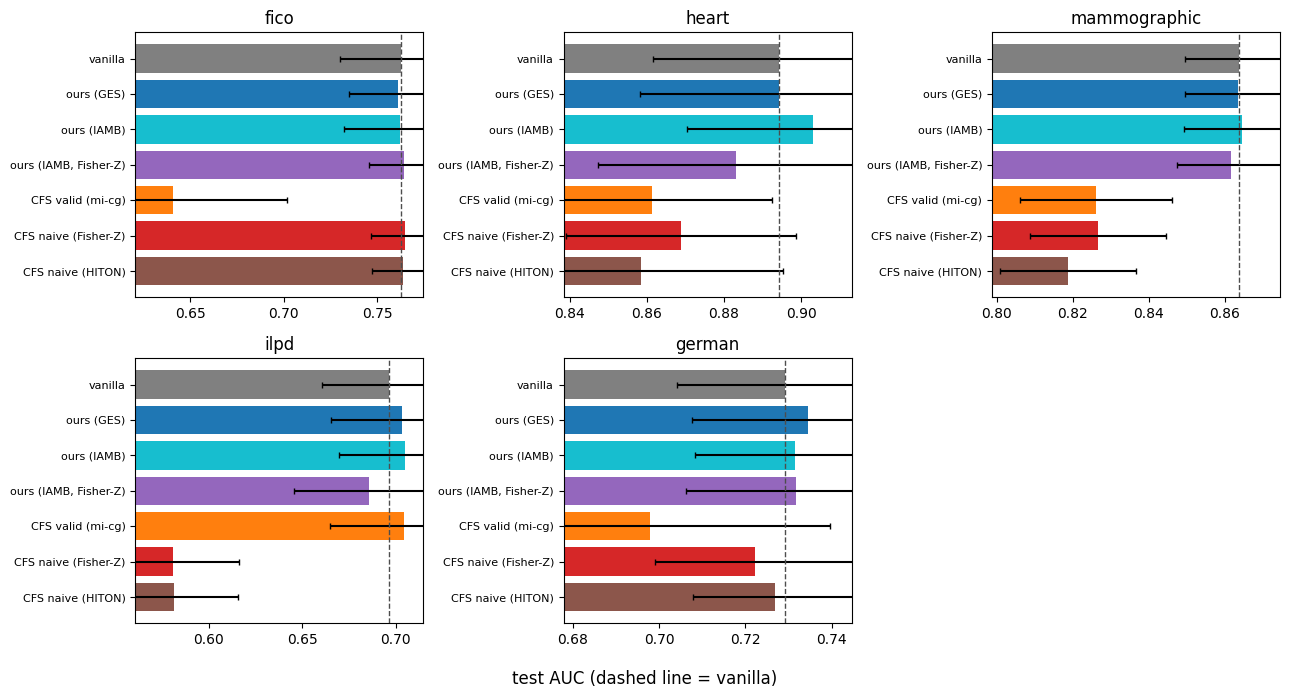

In [5]:
cr.plot_auc(runs)

*Our method clears the CFS baselines on every benchmark and sits on the vanilla line.*

## Selection stability
How reliably each arm picks the same features across splits (0 to 1, higher is steadier).

In [6]:
cr.stability_table(runs)

,vanilla,ours (GES),ours (IAMB),"ours (IAMB, Fisher-Z)",CFS valid (mi-cg),CFS naive (Fisher-Z),CFS naive (HITON)
fico,0.512,0.551,0.558,0.702,0.521,0.691,0.617
heart,0.549,0.539,0.578,0.594,0.534,0.843,0.763
mammographic,0.431,0.485,0.448,0.293,0.601,0.805,0.831
ilpd,0.412,0.602,0.516,0.229,0.823,0.427,0.399
german,0.419,0.498,0.464,0.550,0.452,0.532,0.584


*Our method is more stable than vanilla on most benchmarks. The hard CFS arms can be steadier still, but at much lower accuracy.*

## Validation in the FasterRisk format
Test AUC vs model size *k* for every arm, one panel per benchmark, error bars across splits (mirrors FasterRisk Figure 3/4).

In [7]:
cr.plot_ksweep_grid(cr.load_ksweep())

k-sweep runs not finished yet; re-run this cell when they land.


*AUC climbs with k then plateaus; our method tracks the top, the CFS baselines sit below.*

## Runtime
Wall-clock per deployment on each benchmark: discovery (shared with CFS) plus the fit. **ours (fast)** uses a fixed prior strength; **ours (CV-tuned)** adds the per-dataset μ grid.

In [ ]:
rt = cr.load_runtime()
cr.runtime_table(rt)

*The μ-grid is the only slow part and it is ~30–40x the deployed cost; discovery and the fit are seconds even at n=10k.*

## Runtime: the AUC it buys
Test AUC for the same four variants, read across from the time table.

In [ ]:
cr.runtime_auc_table(rt)

*ours (fast) matches the CV-tuned model within ~0.01–0.04 and sits at or above vanilla, so the tuning grid buys no accuracy. CFS hard selection is as fast but loses AUC, sharply on fico.*

## Operating boundary: hepatitis

The method assumes the discovery step is feasible, which needs enough samples per feature. Five benchmarks clear this; hepatitis does not.

In [8]:
cr.samples_per_feature()

,n,features (1-hot),samples/feature
benchmark,,,
fico,10459,46,159.2
mammographic,831,11,52.8
ilpd,583,11,37.1
german,1000,61,11.5
heart,270,22,8.6
hepatitis,155,42,2.6


*Hepatitis has 2.6 samples per feature, more than 3x below the next benchmark, the regime where causal discovery cannot find stable structure.*

In [9]:
cr.boundary_case()

,vanilla AUC,our AUC,prior on (frac of runs)
hepatitis,0.809,0.776,1.0


*Here our method underperforms vanilla. The cause is upstream: at 2.6 samples/feature the discovered prior is diffuse (no feature gets clear weight) yet CV keeps it on in every run, so a noisy prior is applied and costs accuracy. This is the operating boundary, not a failure of the mechanism; a causal prior should come from outside the scarce sample (literature, a larger cohort), which is how the TB application uses it.*

## What this says

- **The prior costs no accuracy** across the five in-regime benchmarks (the parity curve and the AUC table).
- **It never loses to the valid CFS baseline**, and it beats the hard CFS selectors.
- **It picks more stable features**, most clearly when data is scarce.
- **Operating boundary**: below about five samples per feature (hepatitis) discovery yields a noisy prior and the method underperforms; the prior should then come from outside the scarce sample.
- **The honest gap**: in-distribution we cannot show the *causal* part specifically matters; a merely selective prior would do as well. The distinctively causal payoff is out-of-distribution transport, the next experiment to build.